In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve,
                             precision_recall_curve)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed - run: pip install xgboost")

try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except ImportError:
    HAS_SMOTE = False
    print("imbalanced-learn not installed - run: pip install imbalanced-learn")

import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline
print("All libraries imported!")

All libraries imported!


In [37]:
df = pd.read_excel('Loan_Approval_Data.xlsx')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Data Types:")
print(df.dtypes)
df.head()

Shape: (1000, 12)
Columns: ['CustomerID', 'Gender', 'Age', 'Country', 'SubscriptionType', 'MonthlyCharges', 'TotalCharges', 'TenureMonths', 'SupportTickets', 'ContractType', 'PaymentMethod', 'Churn']
Data Types:
CustomerID          int64
Gender                str
Age                 int64
Country               str
SubscriptionType      str
MonthlyCharges      int64
TotalCharges        int64
TenureMonths        int64
SupportTickets      int64
ContractType          str
PaymentMethod         str
Churn               int64
dtype: object


,CustomerID,Gender,Age,Country,SubscriptionType,MonthlyCharges,TotalCharges,TenureMonths,SupportTickets,ContractType,PaymentMethod,Churn
0,1001,Female,45,Saudi Arabia,Standard,167,2171,13,4,Yearly,Cash,0
1,1002,Male,31,UAE,Standard,174,3132,18,6,Monthly,Cash,0
2,1003,Female,24,Kuwait,Basic,106,2756,26,5,Monthly,Credit Card,1
3,1004,Male,51,Kuwait,Standard,158,2686,17,1,Yearly,Credit Card,1
4,1005,Male,48,Egypt,Standard,190,2280,12,5,Yearly,Credit Card,1


In [38]:
print("Dataset Info:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Churn Rate: {df['Churn'].mean():.2%}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print("Churn Distribution:")
print(df['Churn'].value_counts())

Dataset Info:
Rows: 1000, Columns: 12
Churn Rate: 36.50%
Missing Values: 0
Duplicates: 0
Churn Distribution:
Churn
0    635
1    365
Name: count, dtype: int64


In [39]:
df.describe()

,CustomerID,Age,MonthlyCharges,TotalCharges,TenureMonths,SupportTickets,Churn
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,1500.500000,41.401000,190.87700,3518.08300,18.445000,4.039000,0.365000
std,288.819436,13.667663,72.64148,2526.85326,10.292566,2.608502,0.481671
min,1001.000000,18.000000,80.00000,80.00000,1.000000,0.000000,0.000000
25%,1250.750000,30.000000,121.00000,1468.50000,9.000000,2.000000,0.000000
50%,1500.500000,41.000000,191.00000,3047.50000,19.000000,4.000000,0.000000
75%,1750.250000,53.000000,256.25000,5108.50000,27.000000,6.000000,1.000000
max,2000.000000,65.000000,320.00000,11376.00000,36.000000,8.000000,1.000000


In [40]:
for col in df.select_dtypes(include='object').columns:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- Gender ---
Gender
Male      521
Female    479
Name: count, dtype: int64

--- Country ---
Country
UAE             265
Saudi Arabia    255
Egypt           248
Kuwait          232
Name: count, dtype: int64

--- SubscriptionType ---
SubscriptionType
Standard    347
Premium     344
Basic       309
Name: count, dtype: int64

--- ContractType ---
ContractType
Monthly    501
Yearly     499
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Visa           346
Cash           338
Credit Card    316
Name: count, dtype: int64



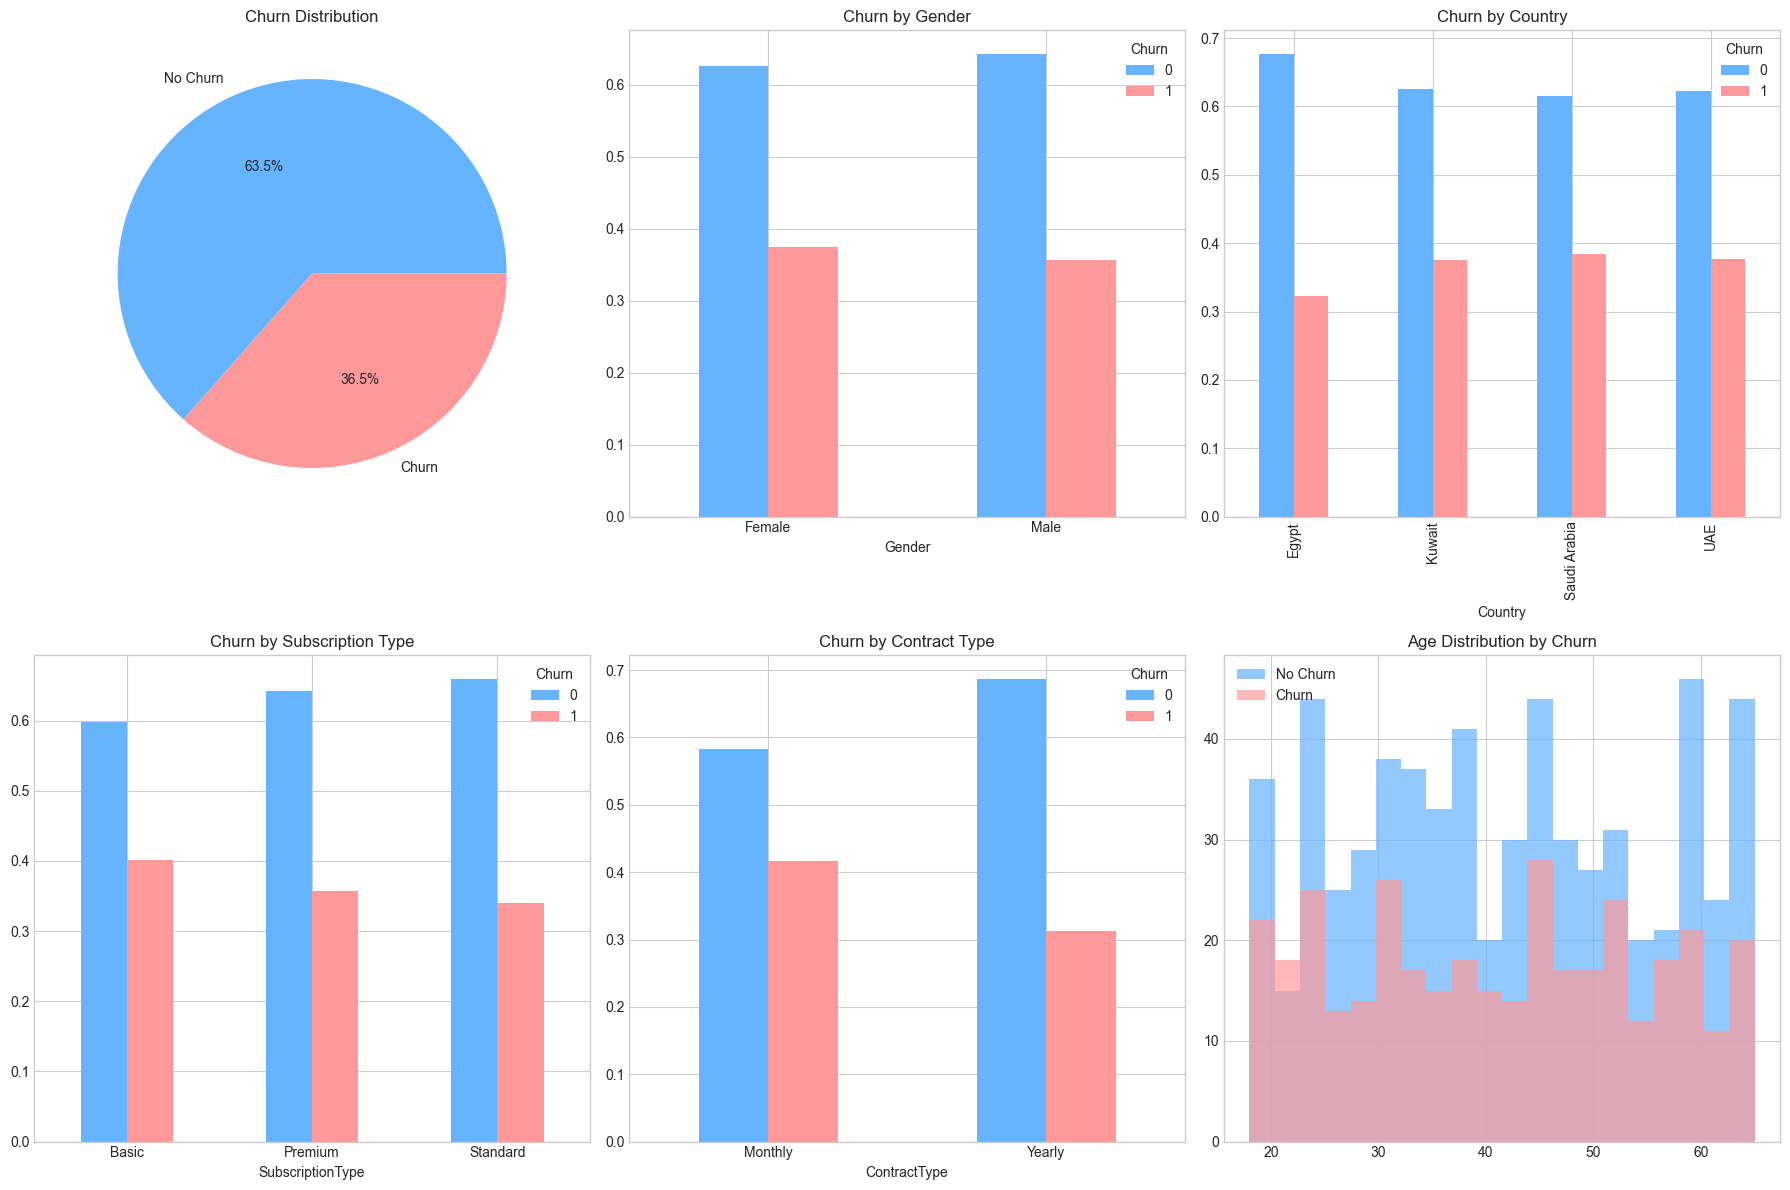

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

churn_counts = df['Churn'].value_counts()
axes[0,0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'])
axes[0,0].set_title('Churn Distribution')

pd.crosstab(df['Gender'], df['Churn'], normalize='index').plot(kind='bar', ax=axes[0,1], color=['#66b3ff', '#ff9999'])
axes[0,1].set_title('Churn by Gender')
axes[0,1].tick_params(axis='x', rotation=0)

pd.crosstab(df['Country'], df['Churn'], normalize='index').plot(kind='bar', ax=axes[0,2], color=['#66b3ff', '#ff9999'])
axes[0,2].set_title('Churn by Country')

pd.crosstab(df['SubscriptionType'], df['Churn'], normalize='index').plot(kind='bar', ax=axes[1,0], color=['#66b3ff', '#ff9999'])
axes[1,0].set_title('Churn by Subscription Type')
axes[1,0].tick_params(axis='x', rotation=0)

pd.crosstab(df['ContractType'], df['Churn'], normalize='index').plot(kind='bar', ax=axes[1,1], color=['#66b3ff', '#ff9999'])
axes[1,1].set_title('Churn by Contract Type')
axes[1,1].tick_params(axis='x', rotation=0)

df[df['Churn']==0]['Age'].hist(ax=axes[1,2], alpha=0.7, bins=20, label='No Churn', color='#66b3ff')
df[df['Churn']==1]['Age'].hist(ax=axes[1,2], alpha=0.7, bins=20, label='Churn', color='#ff9999')
axes[1,2].set_title('Age Distribution by Churn')
axes[1,2].legend()

plt.tight_layout()
plt.show()

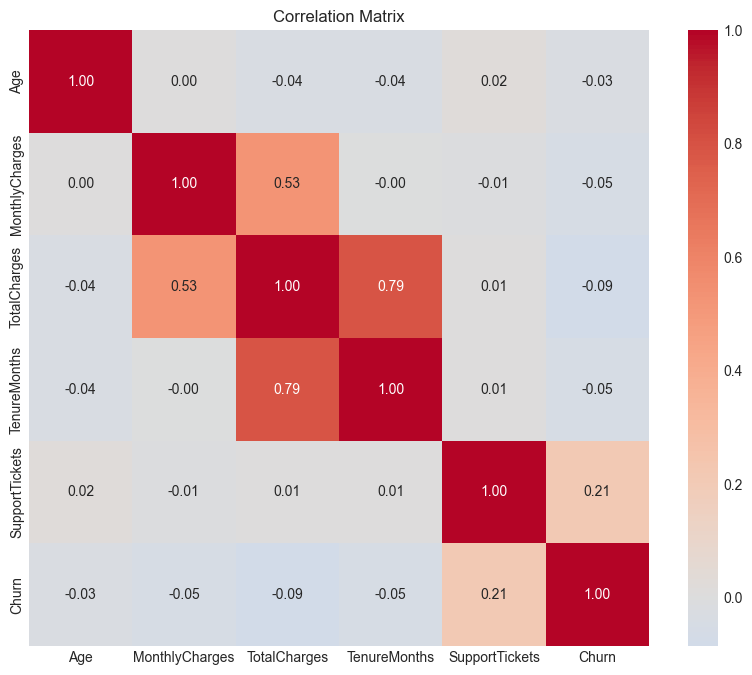

In [42]:
corr = df.select_dtypes(include=[np.number]).drop('CustomerID', axis=1).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [43]:
df_clean = df.copy()
df_clean = df_clean.drop('CustomerID', axis=1)
print(f"Dropped CustomerID. New shape: {df_clean.shape}")

print("Outlier Check (IQR):")
for col in ['Age', 'MonthlyCharges', 'TotalCharges', 'TenureMonths', 'SupportTickets']:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df_clean[(df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)]
    print(f"  {col}: {len(outliers)} outliers")
print("Data is clean!")

Dropped CustomerID. New shape: (1000, 11)
Outlier Check (IQR):
  Age: 0 outliers
  MonthlyCharges: 0 outliers
  TotalCharges: 5 outliers
  TenureMonths: 0 outliers
  SupportTickets: 0 outliers
Data is clean!


## Feature Engineering
Derived features to expose churn signal.

In [44]:
# Engineered features - usually the biggest accuracy gain
df_clean['ChargesPerMonth'] = df_clean['TotalCharges'] / (df_clean['TenureMonths'] + 1)
df_clean['TicketsPerMonth'] = df_clean['SupportTickets'] / (df_clean['TenureMonths'] + 1)
df_clean['HighSupport']     = (df_clean['SupportTickets'] >= 3).astype(int)
df_clean['ShortTenure']     = (df_clean['TenureMonths'] <= 6).astype(int)
df_clean['IsMonthly']       = (df_clean['ContractType'] == 'Monthly').astype(int)
df_clean['ChargeToAge']     = df_clean['MonthlyCharges'] / df_clean['Age']
df_clean['TenureBucket']    = pd.cut(df_clean['TenureMonths'], bins=[-1,6,12,24,1000],
                                     labels=['0-6','7-12','13-24','25+']).astype(str)
print("Engineered features added:", df_clean.shape)
df_clean.head()

Engineered features added: (1000, 18)


,Gender,Age,Country,SubscriptionType,MonthlyCharges,TotalCharges,TenureMonths,SupportTickets,ContractType,PaymentMethod,Churn,ChargesPerMonth,TicketsPerMonth,HighSupport,ShortTenure,IsMonthly,ChargeToAge,TenureBucket
0,Female,45,Saudi Arabia,Standard,167,2171,13,4,Yearly,Cash,0,155.071429,0.285714,1,0,0,3.711111,13-24
1,Male,31,UAE,Standard,174,3132,18,6,Monthly,Cash,0,164.842105,0.315789,1,0,1,5.612903,13-24
2,Female,24,Kuwait,Basic,106,2756,26,5,Monthly,Credit Card,1,102.074074,0.185185,1,0,1,4.416667,25+
3,Male,51,Kuwait,Standard,158,2686,17,1,Yearly,Credit Card,1,149.222222,0.055556,0,0,0,3.098039,13-24
4,Male,48,Egypt,Standard,190,2280,12,5,Yearly,Credit Card,1,175.384615,0.384615,1,0,0,3.958333,7-12


In [45]:
df_processed = df_clean.copy()
le_gender = LabelEncoder()
df_processed['Gender'] = le_gender.fit_transform(df_processed['Gender'])

df_processed = pd.get_dummies(df_processed,
    columns=['Country','SubscriptionType','ContractType','PaymentMethod','TenureBucket'],
    drop_first=False)
bool_cols = df_processed.select_dtypes(include='bool').columns
df_processed = df_processed.astype({col: int for col in bool_cols})

X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training: {X_train.shape[0]}, Testing: {X_test.shape[0]}")
print(f"Train churn rate: {y_train.mean():.2%}")

# Balance the training set ONLY (never touch test data)
if HAS_SMOTE:
    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
    print(f"After SMOTE - Train: {X_train_bal.shape[0]}, churn rate: {y_train_bal.mean():.2%}")
else:
    X_train_bal, y_train_bal = X_train, y_train
    print("SMOTE skipped (package missing) - using class_weight='balanced' instead.")

Training: 800, Testing: 200
Train churn rate: 36.50%
After SMOTE - Train: 1016, churn rate: 50.00%


In [46]:
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=6),
    'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=300,
                                                  max_depth=8, class_weight='balanced', n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=15),
    'SVM':                 SVC(random_state=42, probability=True, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42, n_estimators=300,
                                                     max_depth=3, learning_rate=0.05),
}
if HAS_XGB:
    models['XGBoost'] = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight, eval_metric='logloss',
        use_label_encoder=False, random_state=42, n_jobs=-1)

results = {}
predictions = {}

for name, model in models.items():
    # Tree/boosting models use SMOTE-balanced train; linear/SVM/KNN already use class_weight
    if name in ('Random Forest','Gradient Boosting','XGBoost','Decision Tree'):
        model.fit(X_train_bal, y_train_bal)
    else:
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    predictions[name] = {'y_pred': y_pred, 'y_prob': y_prob}
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
    }
    r = results[name]
    print(f"{name:20s} Acc={r['Accuracy']:.3f}  Prec={r['Precision']:.3f}  "
          f"Rec={r['Recall']:.3f}  F1={r['F1 Score']:.3f}  AUC={r['ROC-AUC']:.3f}")

print("\nAll models trained!")

Logistic Regression  Acc=0.595  Prec=0.457  Rec=0.589  F1=0.515  AUC=0.606
Decision Tree        Acc=0.525  Prec=0.355  Rec=0.370  F1=0.362  AUC=0.541
Random Forest        Acc=0.630  Prec=0.493  Rec=0.507  F1=0.500  AUC=0.653
KNN                  Acc=0.615  Prec=0.450  Rec=0.247  F1=0.319  AUC=0.545
SVM                  Acc=0.555  Prec=0.415  Rec=0.534  F1=0.467  AUC=0.598
Gradient Boosting    Acc=0.615  Prec=0.467  Rec=0.384  F1=0.421  AUC=0.597
XGBoost              Acc=0.615  Prec=0.477  Rec=0.575  F1=0.522  AUC=0.612

All models trained!


Model Comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.595     0.4574  0.5890    0.5150   0.6058
Decision Tree           0.525     0.3553  0.3699    0.3624   0.5407
Random Forest           0.630     0.4933  0.5068    0.5000   0.6529
KNN                     0.615     0.4500  0.2466    0.3186   0.5447
SVM                     0.555     0.4149  0.5342    0.4671   0.5980
Gradient Boosting       0.615     0.4667  0.3836    0.4211   0.5971
XGBoost                 0.615     0.4773  0.5753    0.5217   0.6116


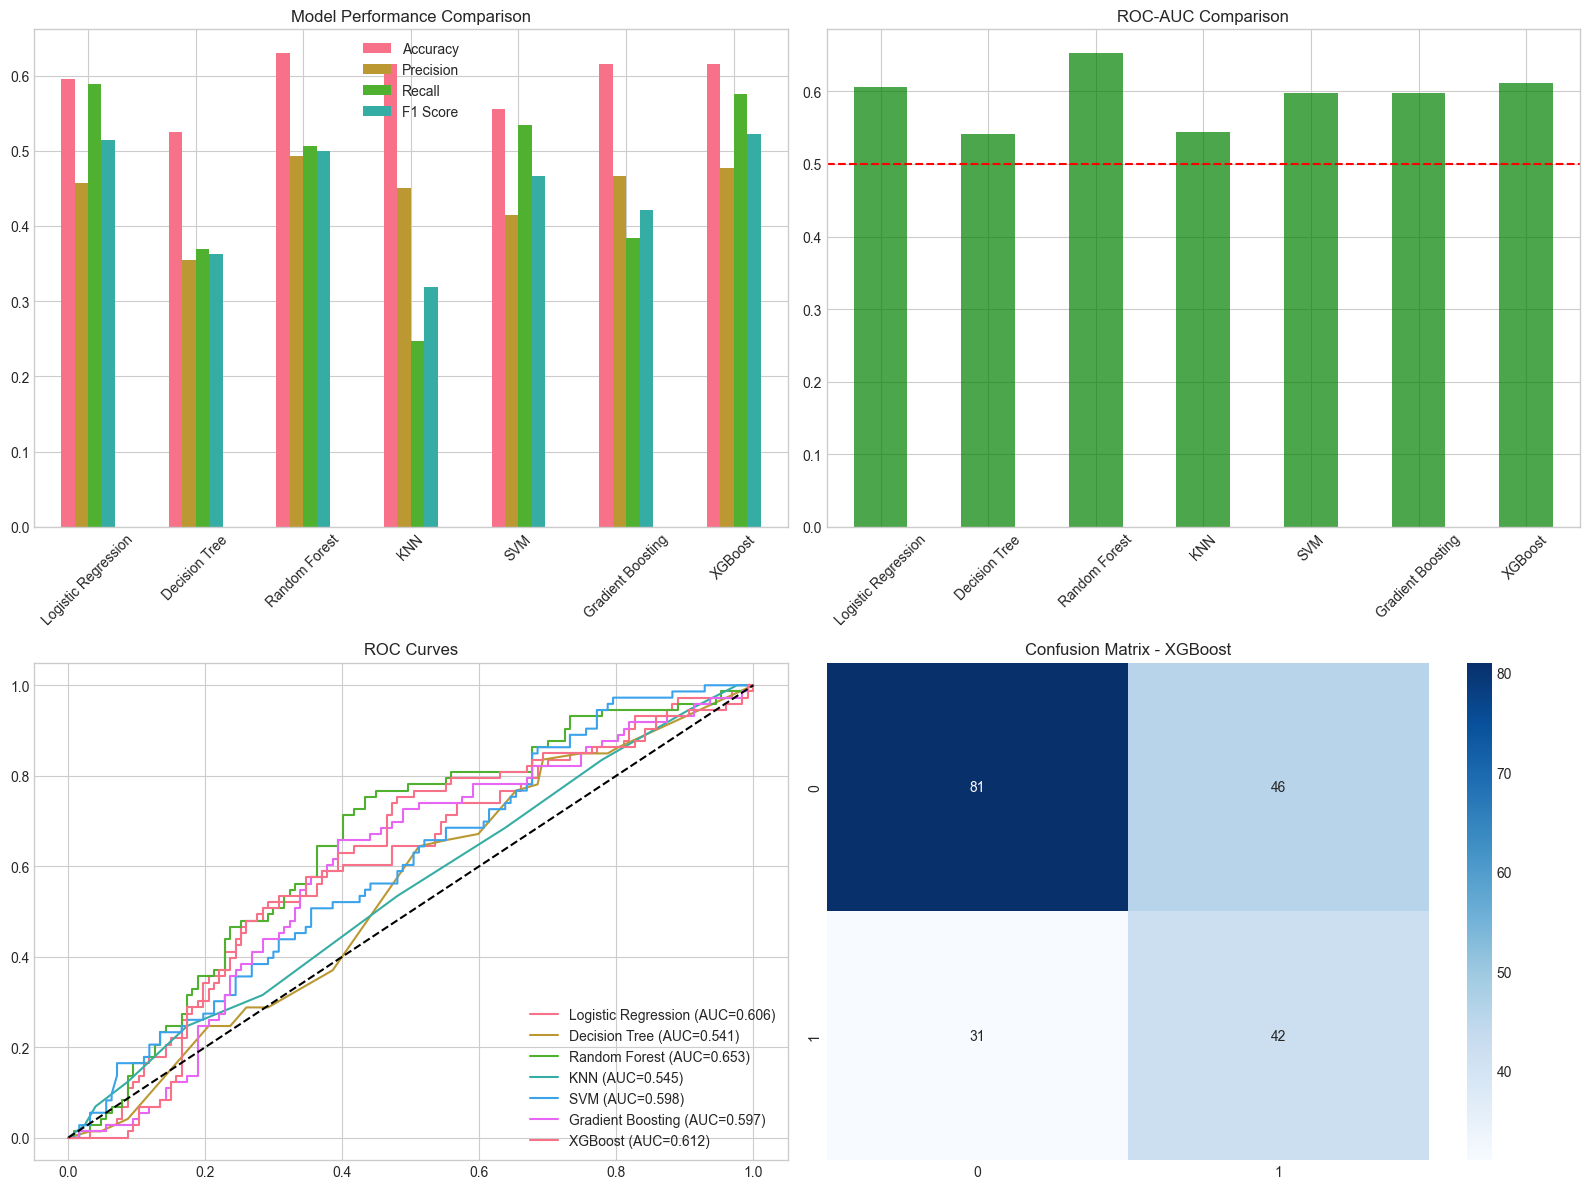

Best Model (F1): XGBoost with F1=0.5217


In [47]:
results_df = pd.DataFrame(results).T
print("Model Comparison:")
print(results_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Model Performance Comparison')
axes[0,0].tick_params(axis='x', rotation=45)

results_df['ROC-AUC'].plot(kind='bar', ax=axes[0,1], color='green', alpha=0.7)
axes[0,1].set_title('ROC-AUC Comparison')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].axhline(y=0.5, color='r', linestyle='--')

for name in models:
    fpr, tpr, _ = roc_curve(y_test, predictions[name]['y_prob'])
    axes[1,0].plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC-AUC']:.3f})")
axes[1,0].plot([0,1], [0,1], 'k--')
axes[1,0].set_title('ROC Curves')
axes[1,0].legend(loc='lower right')

best_name = results_df['F1 Score'].idxmax()
cm = confusion_matrix(y_test, predictions[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,1])
axes[1,1].set_title(f'Confusion Matrix - {best_name}')

plt.tight_layout()
plt.show()

print(f"Best Model (F1): {best_name} with F1={results[best_name]['F1 Score']:.4f}")

In [48]:
print("Tuning Decision Tree...")
dt_params = {'max_depth': [3,5,10,None], 'min_samples_split': [2,10], 'criterion': ['gini','entropy']}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
print(f"Best DT: {dt_grid.best_params_}, F1={dt_grid.best_score_:.4f}")

print("Tuning Random Forest...")
rf_params = {'n_estimators': [100,200], 'max_depth': [5,10,None], 'min_samples_split': [2,5]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
print(f"Best RF: {rf_grid.best_params_}, F1={rf_grid.best_score_:.4f}")

print("Tuning Logistic Regression...")
lr_params = {'C': [0.01,0.1,1,10], 'penalty': ['l1','l2']}
lr_grid = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000, solver='liblinear'), lr_params, cv=5, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train, y_train)
lr_best = lr_grid.best_estimator_
print(f"Best LR: {lr_grid.best_params_}, F1={lr_grid.best_score_:.4f}")

Tuning Decision Tree...
Best DT: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}, F1=0.4497
Tuning Random Forest...
Best RF: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}, F1=0.3781
Tuning Logistic Regression...
Best LR: {'C': 0.01, 'penalty': 'l2'}, F1=0.4092


In [49]:
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = {}

for name, model in [('Decision Tree', DecisionTreeClassifier(random_state=42)),
                    ('Logistic Regression', LogisticRegression(random_state=42, max_iter=1000)),
                    ('Random Forest', RandomForestClassifier(random_state=42, n_estimators=100))]:
    scores = cross_validate(model, X_scaled, y, cv=5, scoring=scoring)
    cv_results[name] = {m: scores['test_'+m].mean() for m in scoring}
    print(f"{name}: F1={cv_results[name]['f1']:.4f}, AUC={cv_results[name]['roc_auc']:.4f}")

cv_df = pd.DataFrame(cv_results).T
print("\nCV Summary:")
print(cv_df.round(4))

Decision Tree: F1=0.4121, AUC=0.5310
Logistic Regression: F1=0.3584, AUC=0.6280
Random Forest: F1=0.3321, AUC=0.5966

CV Summary:
                     accuracy  precision  recall      f1  roc_auc
Decision Tree           0.559     0.4007  0.4274  0.4121   0.5310
Logistic Regression     0.639     0.5121  0.2767  0.3584   0.6280
Random Forest           0.608     0.4376  0.2685  0.3321   0.5966


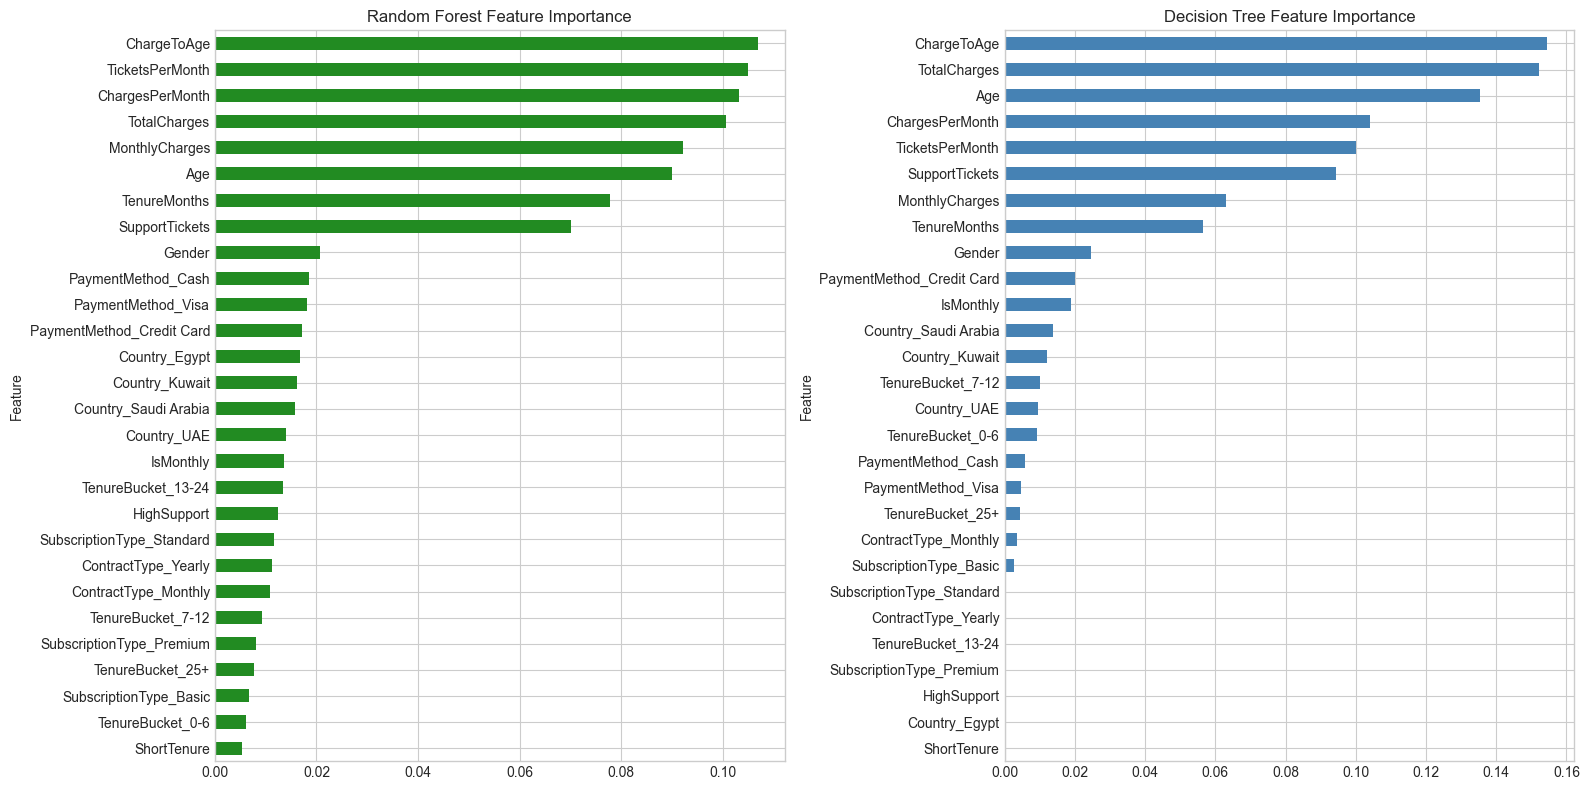

Top 5 Features (RF):
            Feature  Importance
11      ChargeToAge    0.106858
7   TicketsPerMonth    0.105023
6   ChargesPerMonth    0.103226
3      TotalCharges    0.100643
2    MonthlyCharges    0.092229


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values('Importance')
imp.plot(x='Feature', y='Importance', kind='barh', ax=axes[0], color='forestgreen', legend=False)
axes[0].set_title('Random Forest Feature Importance')

dt = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
imp2 = pd.DataFrame({'Feature': X.columns, 'Importance': dt.feature_importances_}).sort_values('Importance')
imp2.plot(x='Feature', y='Importance', kind='barh', ax=axes[1], color='steelblue', legend=False)
axes[1].set_title('Decision Tree Feature Importance')

plt.tight_layout()
plt.show()

print("Top 5 Features (RF):")
print(imp.sort_values('Importance', ascending=False).head())

Best model by AUC: Random Forest
 threshold  accuracy  precision   recall       f1
      0.20     0.400   0.374332 0.958904 0.538462
      0.25     0.465   0.401163 0.945205 0.563265
      0.30     0.510   0.417219 0.863014 0.562500
      0.35     0.530   0.424460 0.808219 0.556604
      0.40     0.610   0.478632 0.767123 0.589474
      0.45     0.635   0.500000 0.643836 0.562874
      0.50     0.630   0.493333 0.506849 0.500000
      0.55     0.630   0.490566 0.356164 0.412698
      0.60     0.635   0.500000 0.232877 0.317757

Best threshold (max F1): 0.4

Final classification report:
              precision    recall  f1-score   support

    No Churn       0.80      0.52      0.63       127
       Churn       0.48      0.77      0.59        73

    accuracy                           0.61       200
   macro avg       0.64      0.64      0.61       200
weighted avg       0.68      0.61      0.61       200



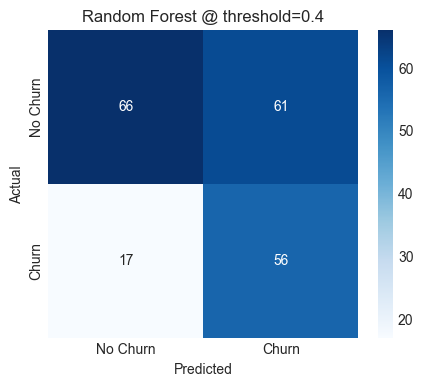

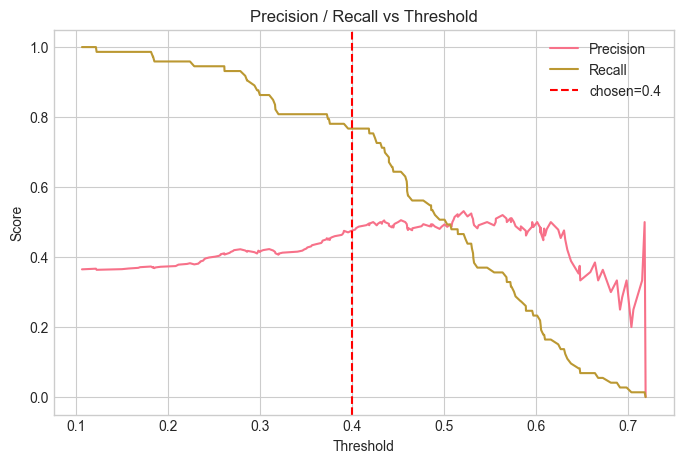

In [51]:
# Pick best model by ROC-AUC and tune its threshold for recall
best_name = max(results, key=lambda n: results[n]['ROC-AUC'])
print(f"Best model by AUC: {best_name}")

probs = predictions[best_name]['y_prob']
prec, rec, thr = precision_recall_curve(y_test, probs)

# Build a table across thresholds
rows = []
for t in np.arange(0.2, 0.65, 0.05):
    pred_t = (probs >= t).astype(int)
    rows.append({
        'threshold': round(t,2),
        'accuracy':  accuracy_score(y_test, pred_t),
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'recall':    recall_score(y_test, pred_t),
        'f1':        f1_score(y_test, pred_t),
    })
thr_df = pd.DataFrame(rows)
print(thr_df.to_string(index=False))

# Pick threshold that maximizes F1 (or recall if you prefer)
best_t = thr_df.loc[thr_df['f1'].idxmax(), 'threshold']
print(f"\nBest threshold (max F1): {best_t}")

final_pred = (probs >= best_t).astype(int)
print("\nFinal classification report:")
print(classification_report(y_test, final_pred, target_names=['No Churn','Churn']))

cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title(f'{best_name} @ threshold={best_t}')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

# Plot precision/recall vs threshold
plt.figure(figsize=(8,5))
plt.plot(thr, prec[:-1], label='Precision')
plt.plot(thr, rec[:-1],  label='Recall')
plt.axvline(best_t, color='r', linestyle='--', label=f'chosen={best_t}')
plt.xlabel('Threshold'); plt.ylabel('Score'); plt.legend()
plt.title('Precision / Recall vs Threshold')
plt.show()

In [52]:
# Save processed data
df_processed.to_csv('processed_data.csv', index=False)
print("Saved: processed_data.csv")

# Save best model (from the cell above: best_name identified by ROC-AUC)
best_model = models[best_name]
print(f"Saving best model: {best_name}")

joblib.dump(best_model, 'best_model.joblib')
print("Saved: best_model.joblib")

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Saved: best_model.pkl")

# Save preprocessors
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(le_gender, 'gender_encoder.joblib')
joblib.dump(X.columns.tolist(), 'feature_names.joblib')
print("Saved: scaler, encoder, feature names")

print("\nAll files saved successfully!")

Saved: processed_data.csv
Saving best model: Random Forest
Saved: best_model.joblib
Saved: best_model.pkl
Saved: scaler, encoder, feature names

All files saved successfully!
